# Urban Delivery Network Under Road Closures

This notebook contains our final experiment. We compare random road closures with closures chosen from the roads used most often by normal delivery routes.

**Research question:** How do random road closures and closures of frequently used roads affect average delivery distance and customer accessibility?

We expected the highest-use closures to cause more disruption. The model is deliberately small and synthetic so every modelling choice can be checked.

## 1. Set up the analysis

The reusable functions are stored in `src/`. The path check below lets the notebook run from either the repository folder or the `notebooks` folder.

In [1]:
from pathlib import Path
import sys

import pandas as pd
from IPython.display import Image, display

project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.run_analysis import (
    create_closure_comparison,
    create_seed_sensitivity,
    create_tie_sensitivity,
    create_travel_cost_results,
    save_main_figures,
    save_network_figure,
)

## 2. Baseline model

The network has 36 locations and 60 two-way roads. It contains three restaurants and 15 customers. Each road receives a distance from 1 to 5 units using seed 42. The value can differ between roads, but it stays fixed throughout the comparison.

A customer is first assigned to the restaurant with the lowest total road distance. NetworkX then finds the shortest weighted path. These normal routes form the baseline.

In [2]:
main_results = create_closure_comparison()

baseline_average = (
    sum(main_results["baseline_distances"].values())
    / len(main_results["baseline_distances"])
)

print("Locations:", main_results["road_network"].number_of_nodes())
print("Roads:", main_results["road_network"].number_of_edges())
print("Restaurants:", main_results["restaurants"])
print("Number of customers:", len(main_results["customers"]))
print("Baseline average distance:", round(baseline_average, 2))

assignment_table = pd.DataFrame([
    {
        "customer": customer,
        "assigned_restaurant": restaurant,
        "baseline_distance": main_results["baseline_distances"][customer]
    }
    for customer, restaurant in main_results["assignments"].items()
])
display(assignment_table)

Locations: 36
Roads: 60
Restaurants: [(0, 0), (5, 5), (0, 5)]
Number of customers: 15
Baseline average distance: 5.07


,customer,assigned_restaurant,baseline_distance
0,"(0, 2)","(0, 0)",3
1,"(0, 4)","(0, 5)",5
2,"(1, 1)","(0, 0)",2
3,"(1, 3)","(0, 0)",6
4,"(1, 4)","(0, 5)",6
5,"(2, 0)","(0, 0)",2
6,"(2, 2)","(0, 0)",6
7,"(2, 5)","(5, 5)",5
8,"(3, 0)","(0, 0)",6
9,"(3, 3)","(0, 0)",9


## 3. Road-use ranking and experimental rules

We count how many baseline routes contain each road. Higher counts give a higher ranking. If counts are equal, coordinates are used as a reproducible tie-break.

Random closures are repeated 100 times at each closure level. We report the mean together with the 10th–90th percentile range, which shows how different random selections can behave.

We also use two service rules:

- **Fixed assignment:** the order stays with its original restaurant.
- **Restaurant reassignment:** the customer changes to the nearest restaurant that still has a path.

This distinction matters because an isolated restaurant does not always mean its customers are disconnected from every other restaurant.

In [3]:
road_usage_table = pd.DataFrame([
    {"road": str(road), "baseline_routes_using_road": count}
    for road, count in main_results["road_usage"].most_common()
])
display(road_usage_table.head(15))

,road,baseline_routes_using_road
0,"((0, 0), (1, 0))",6
1,"((1, 0), (1, 1))",4
2,"((5, 4), (5, 5))",4
3,"((0, 0), (0, 1))",2
4,"((0, 1), (0, 2))",2
5,"((0, 4), (0, 5))",2
6,"((1, 0), (2, 0))",2
7,"((1, 1), (2, 1))",2
8,"((2, 1), (3, 1))",2
9,"((5, 3), (5, 4))",2


## 4. Main comparison

For reachable customers, the percentage change is

$$rac{	ext{scenario mean distance} - 	ext{comparable baseline mean}}{	ext{comparable baseline mean}}	imes 100.$$

Customers with no path are counted separately in the accessibility result. With restaurant reassignment, a customer is unreachable only when no restaurant has a path to that customer.

In [4]:
comparison = main_results["comparison_table"]

display_columns = [
    "roads_closed",
    "random_flexible_distance_mean",
    "random_flexible_distance_p10",
    "random_flexible_distance_p90",
    "high_use_flexible_distance",
    "random_flexible_reachable_mean",
    "high_use_flexible_reachable",
    "high_use_fixed_reachable",
    "random_runs_equal_or_worse_percent",
]
display(comparison[display_columns].round(2))

,roads_closed,random_flexible_distance_mean,random_flexible_distance_p10,random_flexible_distance_p90,high_use_flexible_distance,random_flexible_reachable_mean,high_use_flexible_reachable,high_use_fixed_reachable,random_runs_equal_or_worse_percent
0,1,2.12,0.00,5.39,14.47,100.0,100.0,100.00,3.0
1,2,3.59,0.00,10.53,17.11,100.0,100.0,100.00,3.0
2,3,6.24,0.00,15.79,51.32,100.0,100.0,100.00,0.0
3,4,8.96,0.00,22.50,105.26,100.0,100.0,46.67,0.0
4,5,13.21,0.00,28.95,105.26,100.0,100.0,46.67,0.0
5,6,14.93,1.32,31.58,107.89,100.0,100.0,46.67,0.0
6,8,22.39,5.26,43.42,107.89,100.0,100.0,46.67,0.0
7,10,29.16,7.89,59.82,109.21,99.8,100.0,46.67,0.0


## 5. Tied-road and network-seed checks

Eight roads tie for the fourth highest-use position. Instead of hiding this choice, we run the four-road experiment once for every valid tied road. We also repeat the four-road comparison with ten road-distance seeds. These checks show which conclusions are stable and which depend on a particular modelling choice.

In [5]:
tie_table = create_tie_sensitivity(main_results)
seed_table = create_seed_sensitivity()

print("All valid fourth-road tie choices:")
display(tie_table.round(2))

print("Four-road result across road-distance seeds:")
display(seed_table.round(2))

All valid fourth-road tie choices:


,choice,tied_road,fixed_distance_increase,fixed_reachable_percentage,flexible_distance_increase,flexible_reachable_percentage
0,1,"((0, 0), (0, 1))",79.41,46.67,105.26,100.0
1,2,"((0, 1), (0, 2))",72.37,100.00,60.53,100.0
2,3,"((0, 4), (0, 5))",59.21,100.00,53.95,100.0
3,4,"((1, 0), (2, 0))",56.58,100.00,51.32,100.0
4,5,"((1, 1), (2, 1))",72.37,100.00,71.05,100.0
5,6,"((2, 1), (3, 1))",59.21,100.00,57.89,100.0
6,7,"((5, 2), (5, 3))",56.58,100.00,51.32,100.0
7,8,"((5, 3), (5, 4))",56.58,100.00,51.32,100.0


Four-road result across road-distance seeds:


,network_seed,random_flexible_distance_mean,high_use_flexible_distance,random_flexible_reachable_mean,high_use_flexible_reachable
0,0,9.78,32.26,100.0,100.0
1,1,4.67,26.67,100.0,100.0
2,2,7.39,83.67,100.0,100.0
3,3,6.45,36.29,100.0,100.0
4,4,8.85,53.93,100.0,100.0
5,5,5.50,34.62,100.0,100.0
6,6,7.34,32.00,100.0,100.0
7,7,6.28,36.56,100.0,100.0
8,8,4.87,29.46,100.0,100.0
9,9,6.88,49.47,100.0,100.0


## 6. Static travel-cost sensitivity check

This optional test keeps the top three ranked roads open but multiplies their edge cost. It shows whether routes respond to a simple cost change. It is **not** a traffic-flow simulation and the cost should not be called exact delivery time.

In [6]:
cost_table = create_travel_cost_results(main_results)
display(cost_table.round(2))

,cost_multiplier,travel_cost_increase,routes_changed,customers_reachable
0,1.00,0.00,0,100.0
1,1.25,4.61,0,100.0
2,1.50,9.21,1,100.0
3,2.00,15.79,4,100.0
4,3.00,23.68,4,100.0


## 7. Save and show the final evidence

In [7]:
results_directory = project_root / "results"
figures_directory = project_root / "figures"
results_directory.mkdir(exist_ok=True)
figures_directory.mkdir(exist_ok=True)

comparison.round(4).to_csv(
    results_directory / "closure_comparison_results.csv", index=False
)
main_results["random_runs_table"].round(4).to_csv(
    results_directory / "random_run_results.csv", index=False
)
tie_table.round(4).to_csv(
    results_directory / "tie_sensitivity_results.csv", index=False
)
seed_table.round(4).to_csv(
    results_directory / "network_seed_results.csv", index=False
)
cost_table.round(4).to_csv(
    results_directory / "travel_cost_results.csv", index=False
)

save_main_figures(main_results, tie_table, seed_table, cost_table)
save_network_figure(main_results)
print("Tables and figures saved successfully.")

Tables and figures saved successfully.


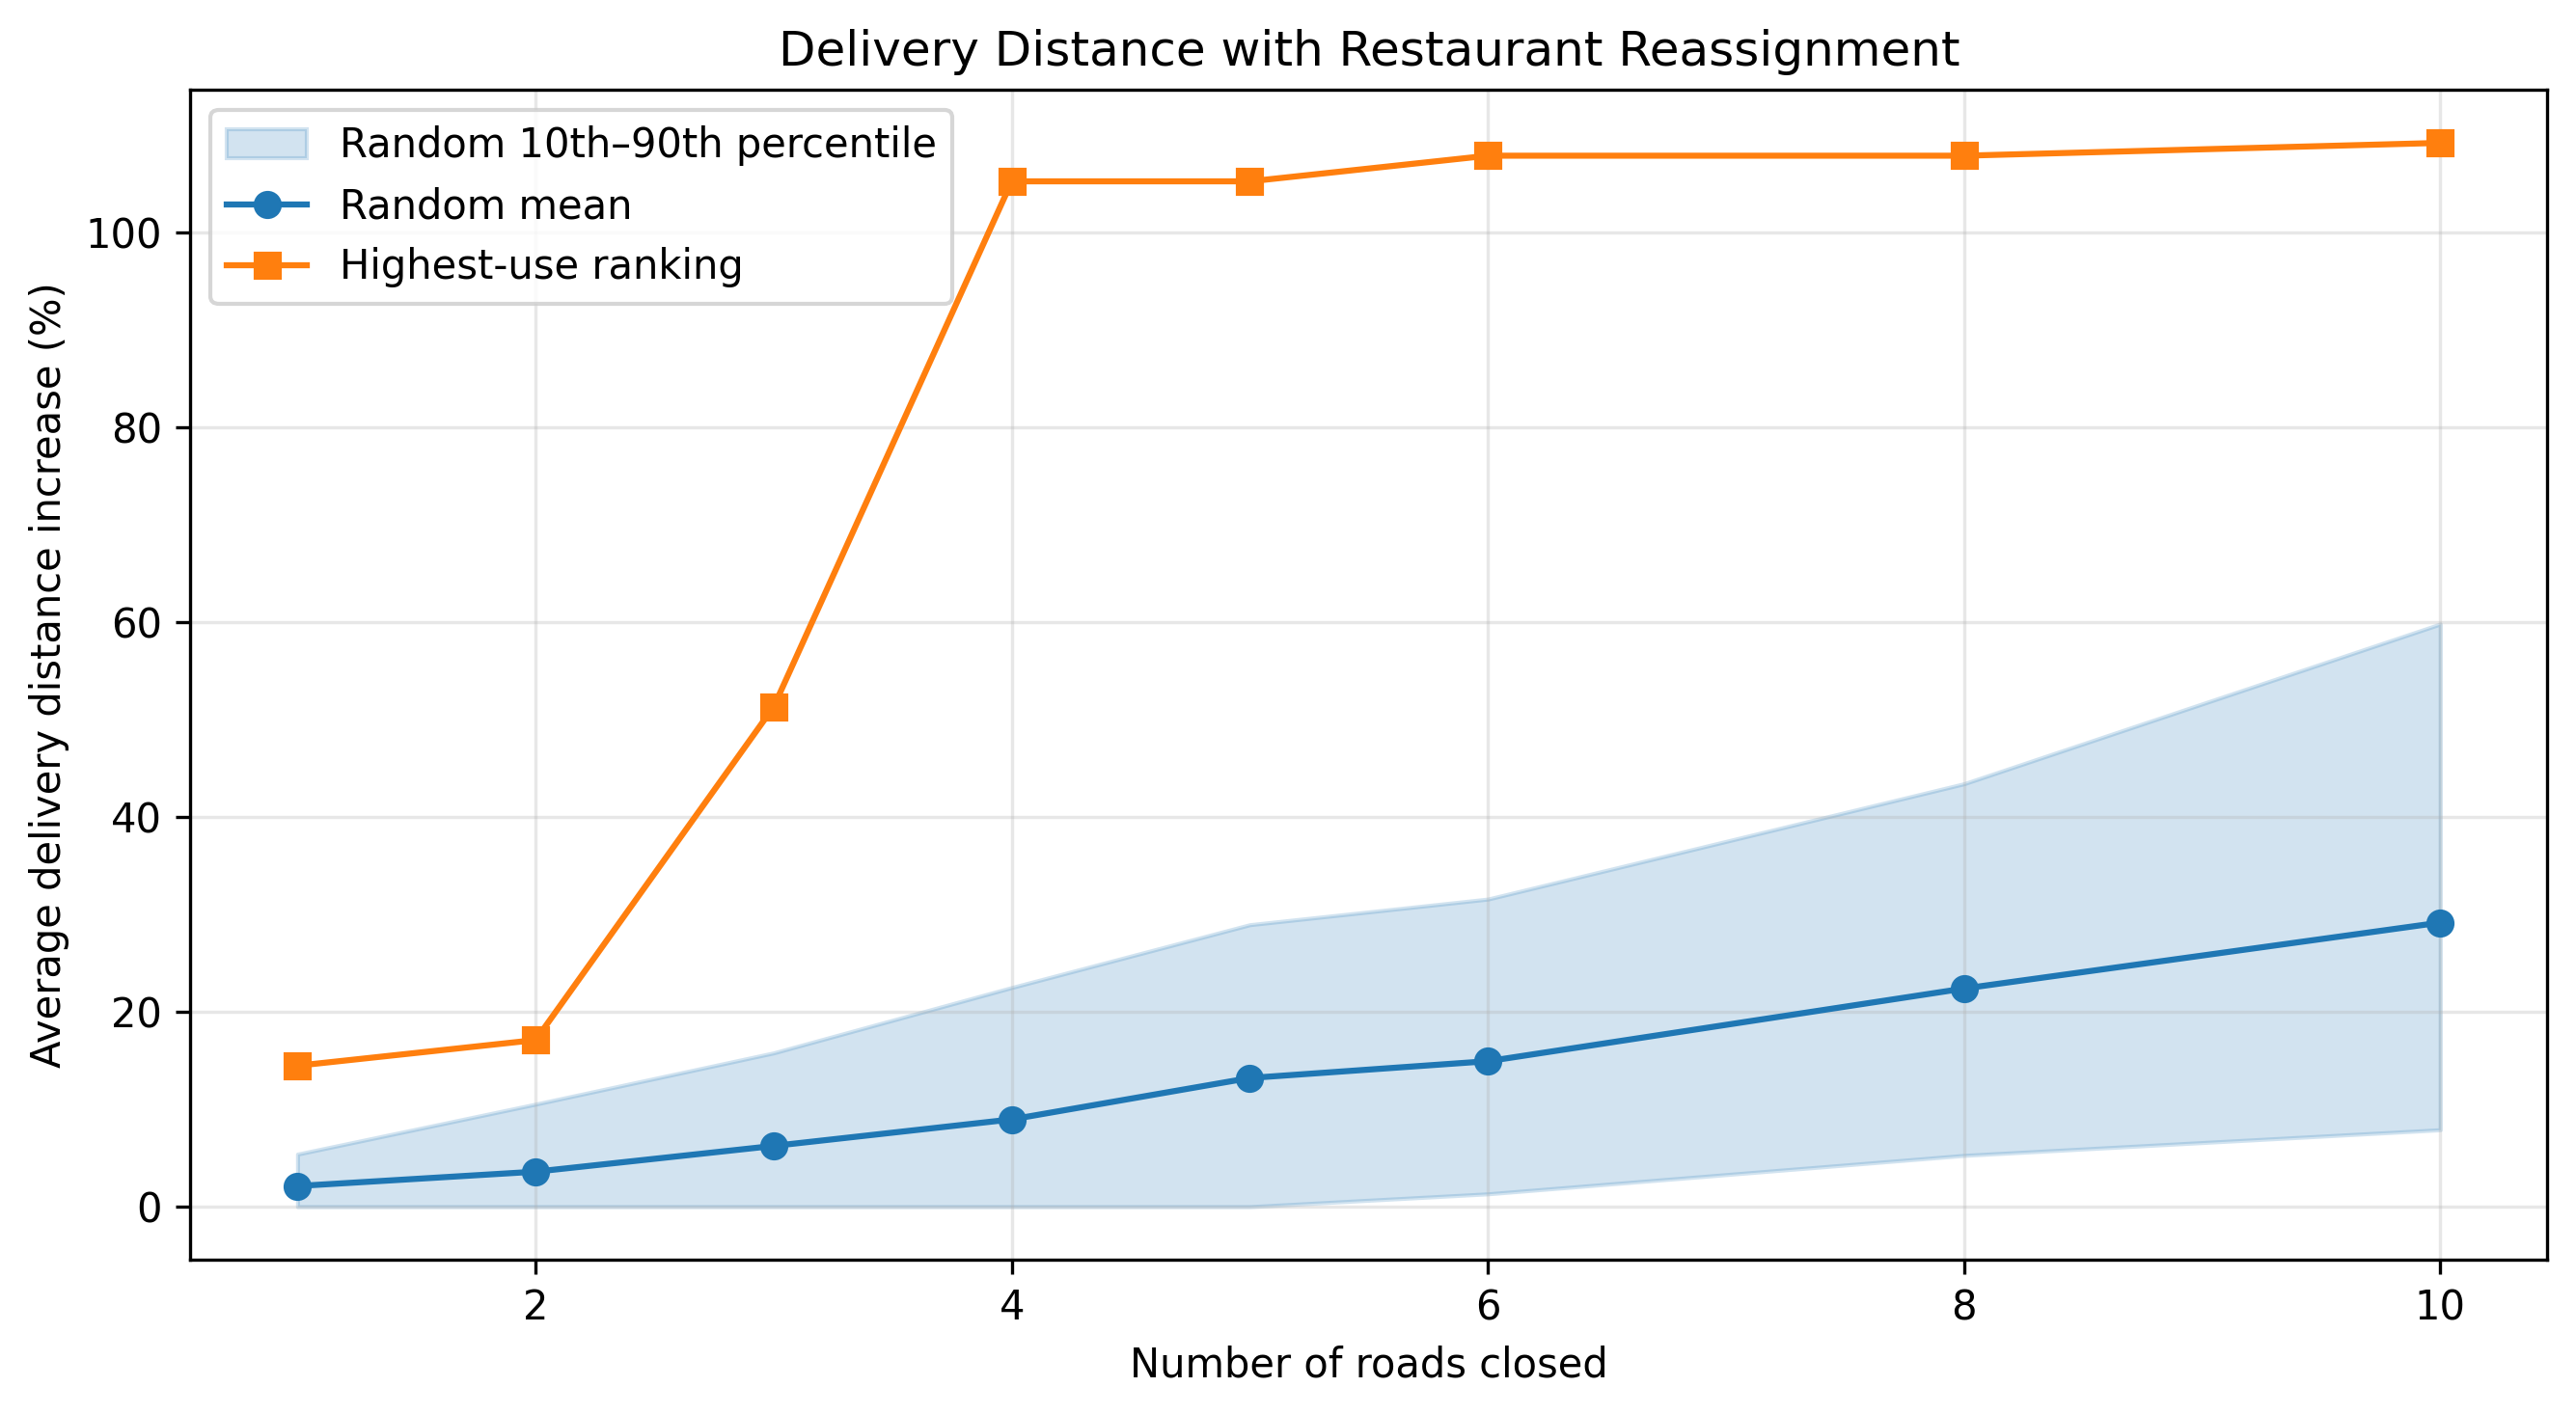

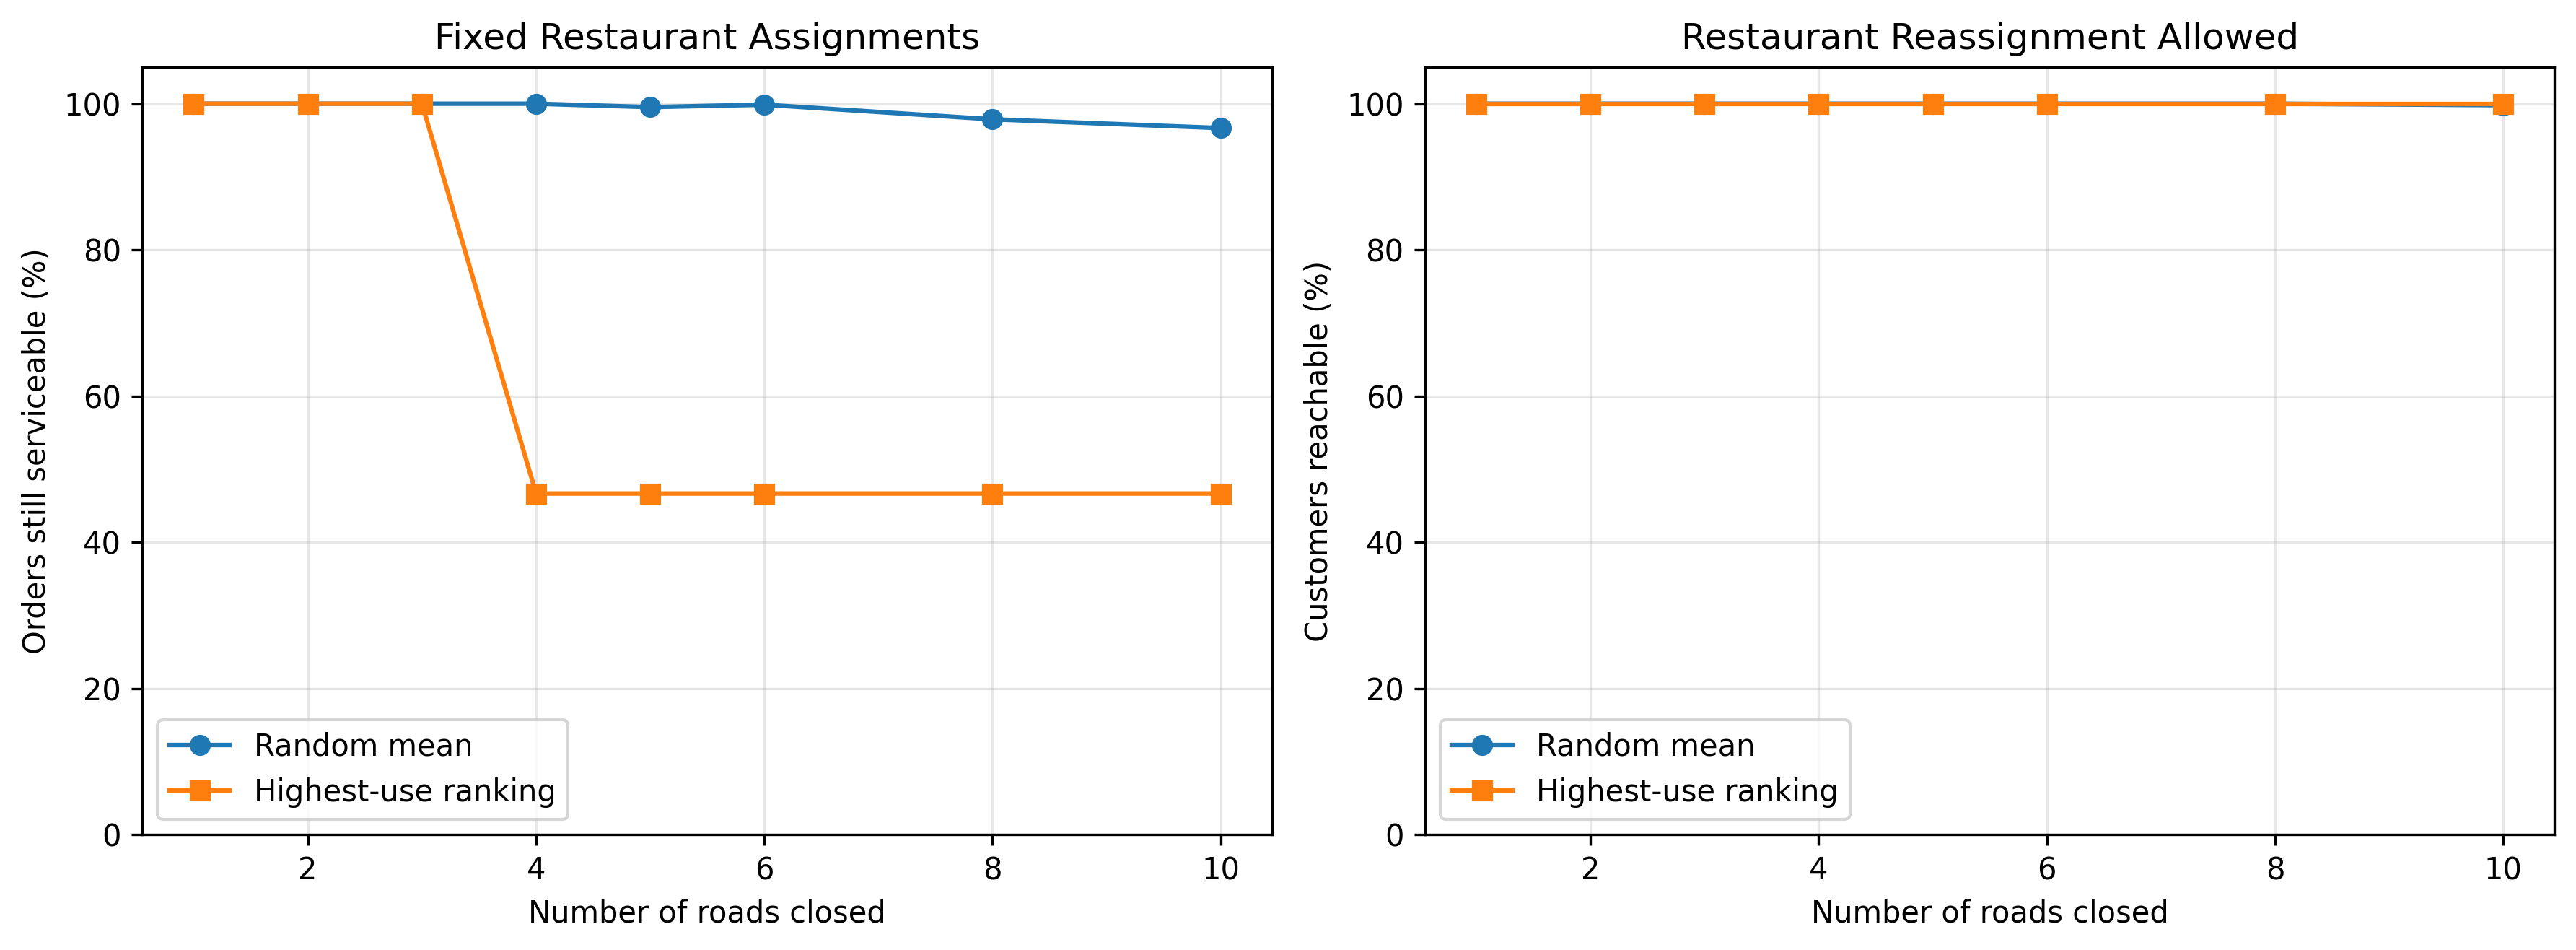

In [8]:
display(Image(filename=str(figures_directory / "distance_comparison.png")))
display(Image(filename=str(figures_directory / "reachability_comparison.png")))

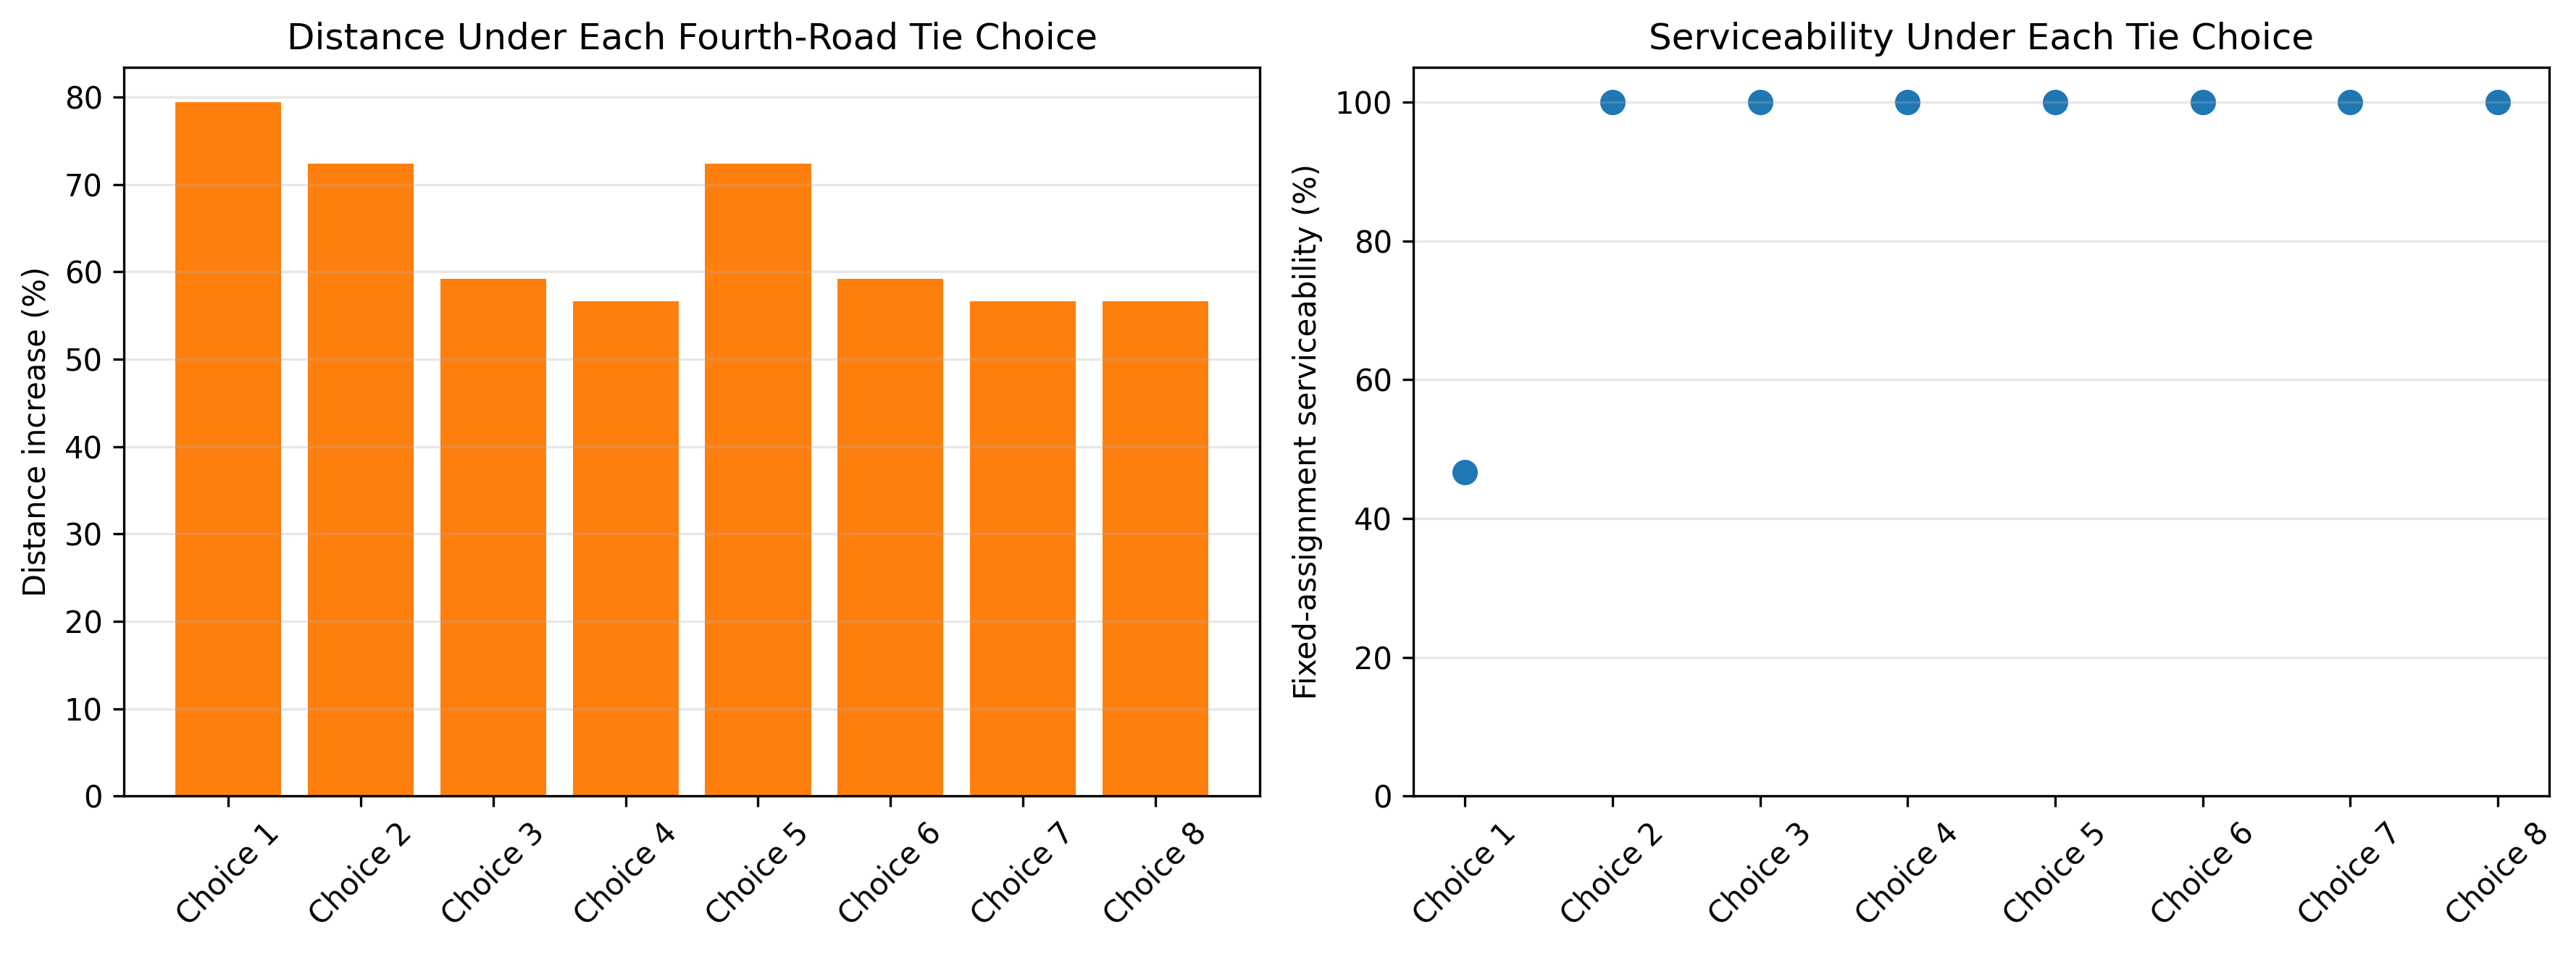

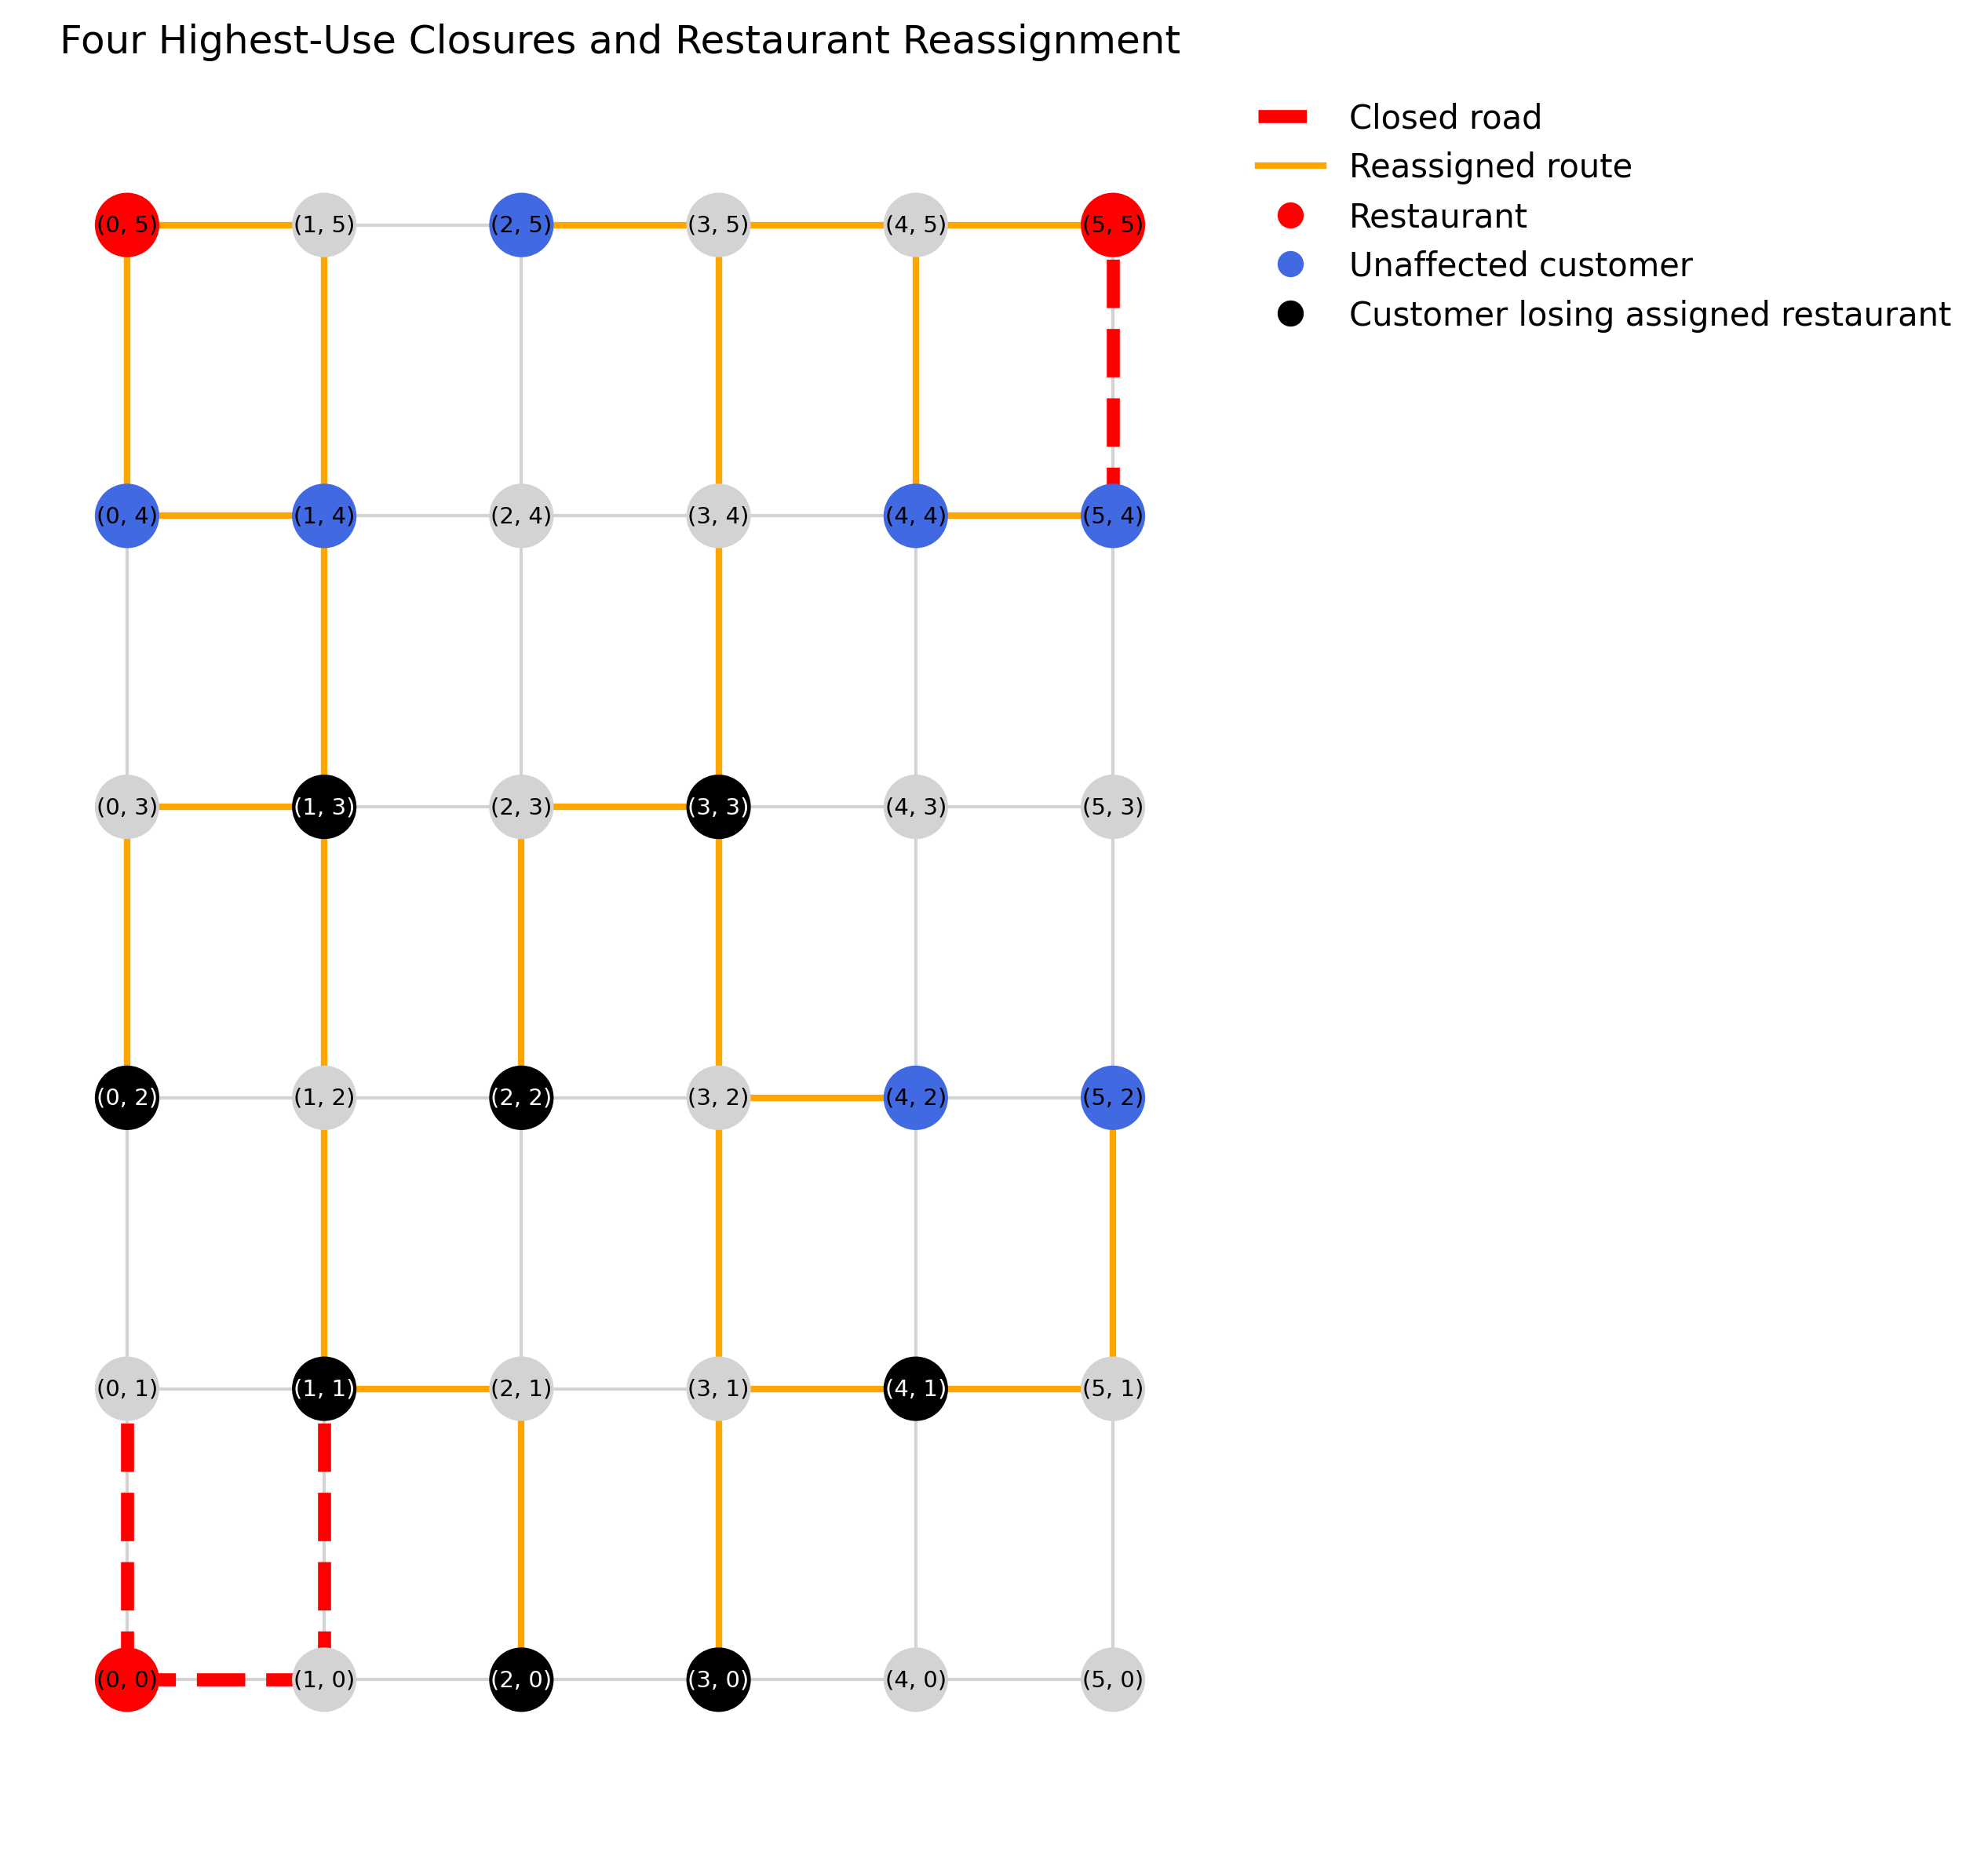

In [9]:
display(Image(filename=str(figures_directory / "tie_sensitivity.png")))
display(Image(filename=str(figures_directory / "high_use_closure_network.png")))

## 8. What we found

Highest-use closures produced a larger distance increase than the random mean at every closure level when restaurant reassignment was allowed. At four closures, the random mean increase was 8.96%, while the selected highest-use case increased distance by 105.26%. None of the 100 random four-road runs was as severe.

Under fixed assignments, the chosen four-road case left only 46.67% of orders serviceable because restaurant `(0, 0)` was isolated. This does not mean those eight customers were physically disconnected: after reassignment, every customer could reach another restaurant.

The tied-road test also changed the interpretation. All eight fourth-road choices increased fixed-assignment distance by between 56.58% and 79.41%, but only one choice isolated the restaurant. The distance effect was consistent, while the exact serviceability drop depended on the tie-break.

Across ten road-distance seeds, highest-use closures still caused a larger four-road distance increase than the random mean. This supports the main pattern within our synthetic design, although it does not prove that every real city would behave the same way.

## 9. Limitations and conclusion

The model uses a regular synthetic grid, fixed road distances and shortest-path drivers. It does not include one-way streets, live traffic, driver capacity, changing orders or interaction between deliveries. Baseline usage is also fixed before the closures instead of being ranked again after every removal.

Within these assumptions, the results support our hypothesis: closing roads used by many baseline delivery routes usually caused much larger detours than random closures. The reassignment and tie checks were important because they stopped us from incorrectly describing an isolated restaurant as complete customer disconnection.

## Reproducibility

From the main project folder, run:

```bash
python -m pytest
python -m src.run_analysis
```

The first command checks the main functions. The second command rebuilds all final CSV files and figures.